In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Z+jets CRES cell visualization helpers

There are two supported inputs:

1. **Already projected coordinates**: `coords_2d` with shape `(n_events, 2)`.
2. **A pairwise distance matrix**: `dist_matrix` with shape `(n_events, n_events)`, embedded into 2D with classical MDS for visualization only.

The actual cell membership should still be computed from the true CRES/EMD/XMD distances, not from the 2D projection.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def classical_mds_from_distances(D, n_components=2):
    """
    Classical MDS embedding from a pairwise distance matrix.

    Parameters
    ----------
    D : array-like, shape (n_events, n_events)
        Pairwise distances between events.
    n_components : int
        Number of embedding dimensions.

    Returns
    -------
    coords : np.ndarray, shape (n_events, n_components)
        Low-dimensional coordinates for visualization.
    """
    D = np.asarray(D, dtype=float)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError(f"D must be square, got shape {D.shape}")

    # Clean tiny asymmetries / diagonal noise.
    D = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)

    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    positive = np.maximum(evals[:n_components], 0.0)
    coords = evecs[:, :n_components] * np.sqrt(positive)
    return coords


def pca_project(features, n_components=2):
    """
    PCA projection using only NumPy. Useful if your actual event representation
    is an array of features rather than a precomputed distance matrix.
    """
    X = np.asarray(features, dtype=float)
    X = X - np.nanmean(X, axis=0, keepdims=True)
    X = np.nan_to_num(X)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    return X @ vt[:n_components].T


In [7]:
from sklearn.manifold import TSNE

def tsne_from_distance_matrix(D, perplexity=30, random_state=42):
    D = np.asarray(D, dtype=float)

    tsne = TSNE(
        n_components=2,
        metric="precomputed",
        init="random",
        random_state=random_state,
        perplexity=perplexity,
    )

    return tsne.fit_transform(D)

In [ ]:
def plot_cres_cell_actual_points(
    coords_2d,
    weights,
    seed_idx,
    radius,
    ms=200,
    show_cell=True,
    distances_from_seed=None,
    ax=None,
    xylim=None,
    title=None,
    savepath=None,
    rw_inside=True,
    legend=True,
):
    """
    Plot one CRES cell using actual event points.

    Parameters
    ----------
    coords_2d : array-like, shape (n_events, 2)
        2D visualization coordinates for events. These can be PCA/MDS coordinates.
    weights : array-like, shape (n_events,)
        Event weights. Positive weights are drawn as positive events; negative weights
        are drawn as negative events.
    seed_idx : int
        Index of the seed event.
    radius : float
        Cell radius in the true distance metric.
    distances_from_seed : array-like, optional
        True CRES/EMD/XMD distances from the seed event to all events.
        If omitted, membership is computed in the 2D projected plane, which is only
        appropriate for a pure cartoon.
    ax : matplotlib axis, optional
    xylim : tuple, optional
        ((xmin, xmax), (ymin, ymax))
    title : str, optional
    savepath : str or Path, optional
        If False, only draw the seed and events inside the true-radius cell.
    legend : bool, optional
        If False, skip drawing a legend on this axis (useful when combining
        several of these plots into one figure with a single shared legend).

    Returns
    -------
    fig, ax, inside
        The figure, axis, and boolean mask for events inside the cell.
    """
    coords_2d = np.asarray(coords_2d, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if coords_2d.ndim != 2 or coords_2d.shape[1] != 2:
        raise ValueError(f"coords_2d must have shape (n_events, 2), got {coords_2d.shape}")
    if len(weights) != len(coords_2d):
        raise ValueError(f"weights and coords_2d length mismatch: {len(weights)} vs {len(coords_2d)}")

    seed_xy = coords_2d[seed_idx]
    rel = coords_2d - seed_xy

    if distances_from_seed is None:
        # Cartoon-only fallback: circle membership in the 2D projection.
        distances_from_seed = np.sqrt(np.sum(rel**2, axis=1))
        circle_radius_for_plot = radius
        xlabel = "Projected coordinate 1 relative to seed"
        ylabel = "Projected coordinate 2 relative to seed"
    else:
        # Physics membership: use true distances for cell membership.
        # The drawn circle is a visual guide in projected coordinates; MDS/PCA does not
        # preserve all pairwise distances exactly.
        distances_from_seed = np.asarray(distances_from_seed, dtype=float)
        if len(distances_from_seed) != len(coords_2d):
            raise ValueError("distances_from_seed must have one entry per event")

        # Put the drawn circle on the same visual scale as the projected points.
        finite = np.isfinite(distances_from_seed) & (distances_from_seed > 0)
        projected_dist = np.sqrt(np.sum(rel**2, axis=1))
        if np.any(finite):
            scale = np.nanmedian(projected_dist[finite] / distances_from_seed[finite])
        else:
            scale = 1.0
        if not np.isfinite(scale) or scale <= 0:
            scale = 1.0
        circle_radius_for_plot = radius * scale
        xlabel = "MDS/PCA coordinate 1 relative to seed"
        ylabel = "MDS/PCA coordinate 2 relative to seed"
    print(distances_from_seed)
    inside = np.abs(distances_from_seed) <= radius
    positive = weights >= 0
    negative = weights < 0

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    ms = ms

    if rw_inside:
        print("inside ", np.sum(inside))
        print("initial weights", weights[0])
        weights_sum = np.sum(weights[inside])/np.sum(inside)
        print("new weight", weights_sum)
        rw_scale = weights_sum/abs(weights[0])
        print("RW scale ", rw_scale)
        ax.scatter(rel[inside, 0], rel[inside, 1],
               marker='.', s=int(abs(rw_scale)*ms), label='Reweighted events', color="orange")
        ax.scatter(rel[positive & ~inside, 0], rel[positive & ~inside, 1],
               marker='.', s=ms, label='Positive events', alpha=1, color="orange")
        ax.scatter(rel[negative & ~inside, 0], rel[negative & ~inside, 1],
               marker='.', s=ms, label='Negative events', alpha=1, color="teal")
    else:
        ax.scatter(rel[positive, 0], rel[positive, 1],
               marker='.', s=ms, label='Positive events', alpha=1, color="orange")
        ax.scatter(rel[negative, 0], rel[negative, 1],
               marker='.', s=ms, label='Negative events', alpha=1, color="teal")
    ax.scatter([0], [0], marker='x', s=80, label='Seed event', color='red')
    if show_cell:
        circle = plt.Circle((0, 0), radius=circle_radius_for_plot,
                        fill=False, linestyle='--', linewidth=2,
                        label='Cell')
        ax.add_patch(circle)
        title_str = f"Z+jets cell: seed={seed_idx}, radius={radius:g}"
    else:
        title_str = f"Z+jets cell: seed={seed_idx}"

    if xylim is not None:
        ax.set_xlim(*xylim[0])
        ax.set_ylim(*xylim[1])
    else:
        # Robust symmetric limits around seed.
        drawn = rel
        print("drawn", drawn)
        if len(drawn) == 0:
            lim = circle_radius_for_plot * 1.25
        else:
            lim = np.nanpercentile(np.abs(drawn), 98)
            lim = max(lim, circle_radius_for_plot) * 1.25
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title or title_str)
    if legend:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    if savepath is not None:
        savepath = Path(savepath)
        fig.savefig(savepath, bbox_inches='tight', dpi=150)

    return fig, ax, inside


In [ ]:
def plot_cres_cell_before_after(
    coords_2d,
    weights,
    seed_idx,
    radius,
    ms=200,
    distances_from_seed=None,
    xylim=None,
    titles=("Before reweighting", "After reweighting"),
    savepath=None,
    figsize=(16, 6),
):
    """
    Plot a CRES cell before and after reweighting side by side in one figure,
    with a shared legend and equation space in the middle.

    Thin wrapper around `plot_cres_cell_actual_points`: calls it once with
    `rw_inside=False` (before) and once with `rw_inside=True` (after), using
    the same coords/weights/seed/radius for both panels.

    Returns
    -------
    fig, axes, inside
        The figure, the (before, after) axes, and the boolean inside-cell mask.
    """
    # Use GridSpec to create space in the middle for legend and equation
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 0.6, 1], wspace=0.1)
    
    ax_before = fig.add_subplot(gs[0, 0])
    ax_middle = fig.add_subplot(gs[0, 1])
    ax_after = fig.add_subplot(gs[0, 2])
    
    # Hide the middle axis (it will hold legend and equation)
    ax_middle.axis('off')

    _, ax_before, _ = plot_cres_cell_actual_points(
        coords_2d=coords_2d,
        weights=weights,
        seed_idx=seed_idx,
        radius=radius,
        ms=ms,
        distances_from_seed=distances_from_seed,
        ax=ax_before,
        xylim=xylim,
        title=titles[0],
        rw_inside=False,
        legend=False,
    )

    _, ax_after, inside = plot_cres_cell_actual_points(
        coords_2d=coords_2d,
        weights=weights,
        seed_idx=seed_idx,
        radius=radius,
        ms=ms,
        distances_from_seed=distances_from_seed,
        ax=ax_after,
        xylim=xylim,
        title=titles[1],
        rw_inside=True,
        legend=False,
    )

    # "After" has the extra "Reweighted events" handle; pull from both axes
    # and de-duplicate by label so the shared legend covers everything drawn.
    legend_order = ['Reweighted events', 'Positive events', 'Negative events', 'Seed event', 'Cell']
    handles_by_label = {}
    for ax in (ax_after, ax_before):
        h, l = ax.get_legend_handles_labels()
        for hi, li in zip(h, l):
            handles_by_label.setdefault(li, hi)

    labels = [l for l in legend_order if l in handles_by_label]
    handles = [handles_by_label[l] for l in labels]

    # Add legend to the middle panel, centered vertically
    ax_middle.legend(handles, labels, loc='center', fontsize=10, 
                     frameon=False, title='', labelspacing=1.2)

    # Add arrow and equation space below legend
    # Arrow from before to after
    arrow = fig.text(0.5, 0.55, '→', ha='center', va='center', 
                    fontsize=40, color='#2ecc71', weight='bold')

    # Leave space for equation - you can add it programmatically or manually
    # Equation placeholder text (can be replaced with actual LaTeX rendering)
    fig.text(0.5, 0.35, r'$w_i \to \frac{\sum_{j \in \text{Cell}} w_j}{\sum_{j \in \text{Cell}} |w_j|} |w_i|$', 
            ha='center', va='center', fontsize=11, style='italic', 
            bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black', linewidth=1.5))

    if savepath is not None:
        fig.savefig(Path(savepath), bbox_inches='tight', dpi=150)

    return fig, (ax_before, ax_after), inside

In [ ]:
# # -------------------------------------------------------------------------
# # OPTION A: You already have actual 2D coordinates for Z+jets events
# # -------------------------------------------------------------------------
# #
# # Replace these names with whatever you have in your analysis.
# #
# points = np.load("/users/lhay/NegativeWeights/hadronization_ttbar_points10k.npy")
# dist_matrix = np.load("/users/lhay/NegativeWeights/distmatrix_ttbar10k.npy")
# weights = np.load("/users/lhay/NegativeWeights/ttbar_weight_10k.npy")
# print(np.shape(points))
# zjets_x=points[:,1]
# print(np.shape(zjets_x))
# zjets_y=points[:,2]
# print(points)
# coords_2d = np.column_stack([zjets_x, zjets_y])
# seed_idx = np.where(weights < 0)[0][0]   # common choice: seed on a negative-weight event
# radius = 100.0

# # If you have the true distances from this seed to all events:
# # distances_from_seed = zjets_dist_matrix[seed_idx]

# fig, ax, inside = plot_cres_cell_actual_points(
#     coords_2d=coords_2d,
#     weights=weights,
#     seed_idx=seed_idx,
#     radius=radius,
#     distances_from_seed=distances_from_seed,
#     savepath='zjets_cres_cell_actual_points.png',
# )
# plt.show()


0.3565
[98.41133571 90.7510298  59.64656738 ... 59.09746021 56.16615051
 90.58644675]


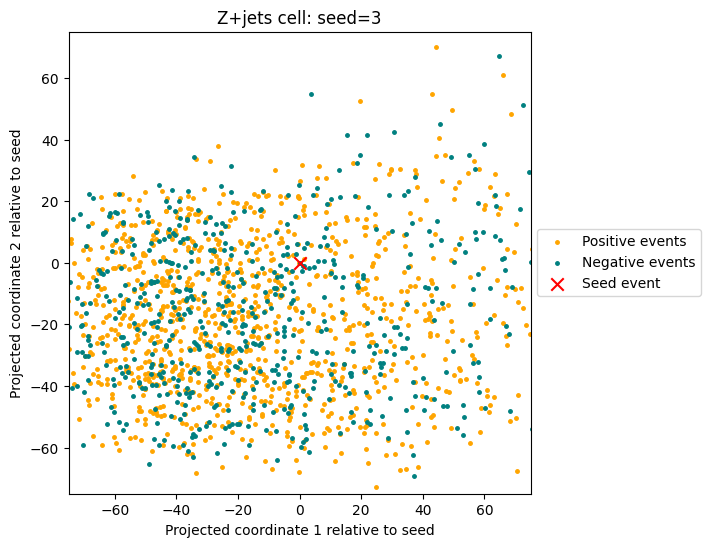

In [ ]:
# -------------------------------------------------------------------------
# OPTION B: You have a Z+jets distance matrix, but no 2D coordinates
# -------------------------------------------------------------------------
#
# For example:
# dist_matrix = np.load('zjets_distance_matrix.npy')
# weights = np.load('zjets_event_weights.npy')
N=2000
# points = np.load("/users/lhay/NegativeWeights/hadronization_ttbar_points10k.npy")
# dist_matrix = np.load("/users/lhay/NegativeWeights/distmatrix_ttbar10k.npy")
# print(np.max(dist_matrix))
# weights = np.load("/users/lhay/NegativeWeights/ttbar_weight_10k.npy")


# Slice it to load only the first 100 rows into memory

points = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/hadronization_points.npy', mmap_mode='r')
points = points[:N].copy()
weights = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy', mmap_mode='r')
weights= weights[:N].copy()
dist_matrix = np.load('/oscar/data/mleblan6/rjain/xmd_groundmetrics/had_100k_distmatrix/full_distmatrix.npy', mmap_mode='r')
dist_matrix= dist_matrix[:N, :N].copy()
frac = np.sum(weights < 0)/len(weights)
print(frac)
# Optional: downsample before MDS if the matrix is large.
# MDS needs an NxN matrix, so this is not what you want for millions of events.

max_events_for_plot = 2000
rng = np.random.default_rng(12345)
if len(weights) > max_events_for_plot:
    # Keep all/most negative weights if possible, then fill with random positives.
    neg_idx = np.where(weights < 0)[0]
    print(np.sum(weights < 0))
    pos_idx = np.where(weights >= 0)[0]
    n_neg_keep = int(frac*max_events_for_plot)
    print(n_neg_keep)
    n_pos_keep = max_events_for_plot-n_neg_keep 
    keep = np.concatenate([
        rng.choice(neg_idx, size=n_neg_keep, replace=False),
        rng.choice(pos_idx, size=n_pos_keep, replace=False),
    ])
else:
    keep = np.arange(len(weights))

D_plot = dist_matrix[np.ix_(keep, keep)]
w_plot = weights[keep]
# coords_2d = classical_mds_from_distances(D_plot)
coords_2d = classical_mds_from_distances(D_plot)
seed_local = np.where(w_plot < 0)[0][0]
radius = 15.0
distances_from_seed = D_plot[seed_local]

fig, ax, inside = plot_cres_cell_actual_points(
    coords_2d=coords_2d,
    weights=w_plot,
    seed_idx=seed_local,
    radius=radius,
    rw_inside=False,
    show_cell=False,
    savepath='zjets_cell0.png',
    xylim = [[-75,75], [-75,75]],
    ms=25
)
plt.show()


0.3565
[98.41133571 90.7510298  59.64656738 ... 59.09746021 56.16615051
 90.58644675]


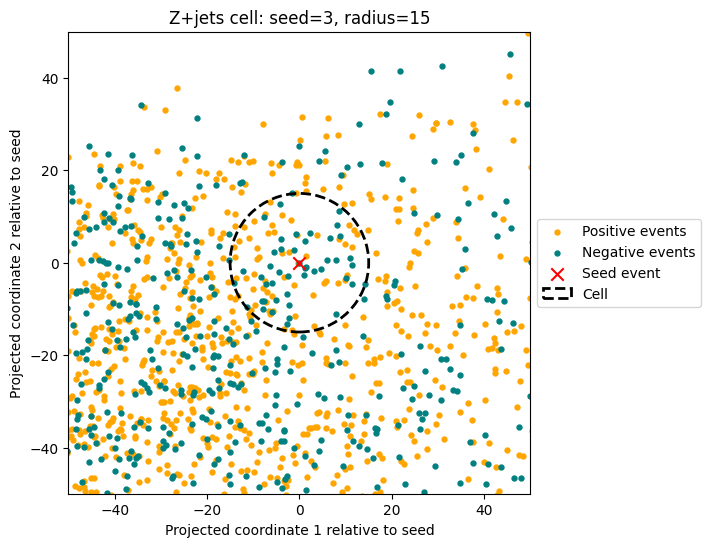

In [ ]:
# -------------------------------------------------------------------------
# OPTION B: You have a Z+jets distance matrix, but no 2D coordinates
# -------------------------------------------------------------------------
#
# For example:
# dist_matrix = np.load('zjets_distance_matrix.npy')
# weights = np.load('zjets_event_weights.npy')
# points = np.load("/users/lhay/NegativeWeights/hadronization_ttbar_points10k.npy")
# dist_matrix = np.load("/users/lhay/NegativeWeights/distmatrix_ttbar10k.npy")
# print(np.max(dist_matrix))
# weights = np.load("/users/lhay/NegativeWeights/ttbar_weight_10k.npy")
frac = np.sum(weights < 0)/len(weights)
print(frac)
# Optional: downsample before MDS if the matrix is large.
# MDS needs an NxN matrix, so this is not what you want for millions of events.

max_events_for_plot = 2000
rng = np.random.default_rng(12345)
if len(weights) > max_events_for_plot:
    # Keep all/most negative weights if possible, then fill with random positives.
    neg_idx = np.where(weights < 0)[0]
    print(np.sum(weights < 0))
    pos_idx = np.where(weights >= 0)[0]
    n_neg_keep = int(frac*max_events_for_plot)
    print(n_neg_keep)
    n_pos_keep = max_events_for_plot-n_neg_keep 
    keep = np.concatenate([
        rng.choice(neg_idx, size=n_neg_keep, replace=False),
        rng.choice(pos_idx, size=n_pos_keep, replace=False),
    ])
else:
    keep = np.arange(len(weights))

D_plot = dist_matrix[np.ix_(keep, keep)]
w_plot = weights[keep]
coords_2d = classical_mds_from_distances(D_plot)

seed_local = np.where(w_plot < 0)[0][0]
radius = 15.0
distances_from_seed = D_plot[seed_local]

fig, ax, inside = plot_cres_cell_actual_points(
    coords_2d=coords_2d,
    weights=w_plot,
    seed_idx=seed_local,
    radius=radius,
    savepath='zjets_cres_cell_from_distance_matrix.png',
    xylim = [[-50,50], [-50,50]],
    rw_inside=False,
    ms=50
)
plt.show()


0.3565
[98.41133571 90.7510298  59.64656738 ... 59.09746021 56.16615051
 90.58644675]
inside  99
initial weights 0.59126424
new weight 0.05375129454545455


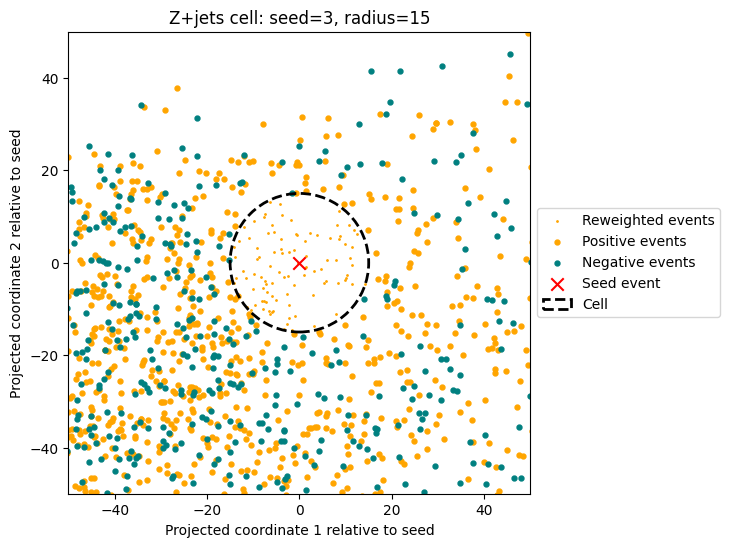

In [ ]:
frac = np.sum(weights < 0)/len(weights)
print(frac)
# Optional: downsample before MDS if the matrix is large.
# MDS needs an NxN matrix, so this is not what you want for millions of events.

max_events_for_plot = 2000
rng = np.random.default_rng(12345)
if len(weights) > max_events_for_plot:
    # Keep all/most negative weights if possible, then fill with random positives.
    neg_idx = np.where(weights < 0)[0]
    print(np.sum(weights < 0))
    pos_idx = np.where(weights >= 0)[0]
    n_neg_keep = int(frac*max_events_for_plot)
    print(n_neg_keep)
    n_pos_keep = max_events_for_plot-n_neg_keep 
    keep = np.concatenate([
        rng.choice(neg_idx, size=n_neg_keep, replace=False),
        rng.choice(pos_idx, size=n_pos_keep, replace=False),
    ])
else:
    keep = np.arange(len(weights))

D_plot = dist_matrix[np.ix_(keep, keep)]
w_plot = weights[keep]
coords_2d = classical_mds_from_distances(D_plot)

seed_local = np.where(w_plot < 0)[0][0]
radius = 15.0
distances_from_seed = D_plot[seed_local]

fig, ax, inside = plot_cres_cell_actual_points(
    coords_2d=coords_2d,
    weights=w_plot,
    seed_idx=seed_local,
    radius=radius,
    savepath='zjets_cres_cell_from_distance_matrix.png',
    xylim = [[-50,50], [-50,50]],
    ms=50
)
plt.show()


[113.95022583 103.41281891  72.02207947 ...  65.15180206  67.40729523
 110.91957092]
[113.95022583 103.41281891  72.02207947 ...  65.15180206  67.40729523
 110.91957092]
inside  1
initial weights 0.59126424
new weight -0.59126424


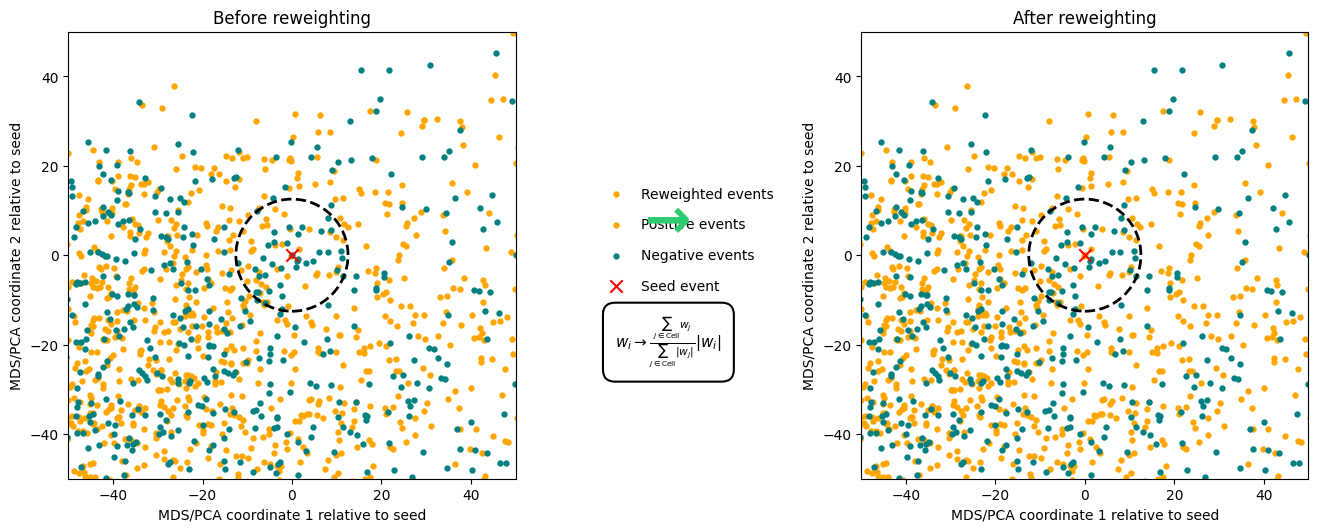

In [14]:
# Before/after reweighting, side by side, with one shared legend.
fig, axes, inside = plot_cres_cell_before_after(
    coords_2d=coords_2d,
    weights=w_plot,
    seed_idx=seed_local,
    radius=radius,
    distances_from_seed=distances_from_seed,
    savepath='zjets_cres_cell_before_after.png',
    xylim=[[-50, 50], [-50, 50]],
    ms=50,
)
plt.show()
